# Librerias necesarias para el analisis de datos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

import seaborn as sns
import hashlib
import os

SEED = 20
np.random.seed(SEED)

url ='https://raw.githubusercontent.com/agustilin/Ev1_grupo_5/refs/heads/main/data/dataset_clientes.csv'
df = pd.read_csv(url)
df = df.drop_duplicates() # Corrected: Drop duplicates here
df.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


# Validacion de integridad de los datos

In [ ]:
def auditar_integridad_y_esquema(ruta_archivo):
    """
    Realiza una auditoría completa del archivo crudo verificando su integridad
    criptográfica (Checksum SHA-256) y validando su esquema estructural básico.

    UTILIDAD PARA EL NEGOCIO Y JUSTIFICACIÓN TÉCNICA:
    1. Verificación de Integridad (Checksum): En un entorno profesional, los datos
       pueden corromperse durante la extracción o transferencia. El hash SHA-256
       actúa como una "huella digital" del archivo. Si un solo byte cambia en el
       origen, el hash será completamente distinto, alertando al equipo de Data
       Engineering antes de que datos corruptos entren al modelo.

    2. Validación de Esquema: Asegura de forma temprana que el archivo contiene
       las variables esperadas (nombres de columnas) antes de invertir recursos
       computacionales en el Pipeline de transformación.

    Parámetros:
    ruta_archivo (str): La ruta del archivo CSV a auditar.

    Retorna:
    str: El hash SHA-256 del archivo si es exitoso.
    """
    print("Iniciando Auditoría de Integridad y Esquema")

    # Inicializamos el objeto que calculará el hash SHA-256.
    sha256_hash = hashlib.sha256()

    try:
        # Abrimos el archivo en modo "rb" (read binary). Es necesario leerlo
        # en binario (como ceros y unos) porque los algoritmos criptográficos
        # como SHA-256 operan a nivel de bytes, no de texto.
        with open(ruta_archivo, "rb") as f:

            # BUCLE DE LECTURA OPTIMIZADA:
            # En lugar de cargar todo el archivo a la memoria (lo que podría
            # colapsar la RAM si el CSV pesa varios GBs), usamos iter() con un lambda.
            # lambda: f.read(4096) -> Lee el archivo en "trozos" (chunks) de 4096 bytes (4KB).

            # b"" -> Es el "centinela" (sentinel). Le dice al iterador: "sigue leyendo
            # trozos de 4KB hasta que el archivo te devuelva un string binario vacío (b""),
            # lo que significa que llegaste al final del archivo".
            for byte_block in iter(lambda: f.read(4096), b""):
                # Por cada trozo de 4KB leído, actualizamos la calculadora de hash.
                sha256_hash.update(byte_block)

        # Una vez procesado todo el archivo, hexdigest() convierte el resultado
        # binario final en una cadena de texto legible (hexadecimal). Esta es
        # nuestra "huella digital" definitiva.
        checksum = sha256_hash.hexdigest()

        # Mostramos mensajes de éxito en consola informando el archivo procesado y su Hash.
        print("INTEGRIDAD: Checksum SHA-256 calculado correctamente.")
        print(f"   -> Archivo: {ruta_archivo}")
        print(f"   -> Hash: {checksum}")

    # Manejo de error específico: Si la ruta que le dimos a la función no existe,
    # capturamos el error y detenemos la función retornando 'None' para evitar
    # que el script completo se rompa.
    except FileNotFoundError:
        print(f"ERROR: No se encontró el archivo en la ruta: {ruta_archivo}")
        return None

    try:
        # Utilizamos pd.read_csv pero con el argumento clave 'nrows=0'.
        # Esto le ordena a Pandas: "Lee solamente la primera fila del CSV (donde
        # están los nombres de las columnas) y construye un DataFrame vacío sin
        # procesar ni un solo registro de datos". Es un escaneo en milisegundos.
        df_esquema = pd.read_csv(ruta_archivo, nrows=0)

        # Extraemos los nombres de esas columnas en una lista estándar de Python.
        columnas_encontradas = df_esquema.columns.tolist()

        # Definimos nuestra lista. Estas son las columnas
        # que el negocio ha definido como obligatorias para que el modelo predictivo
        # (tu Pipeline) pueda funcionar correctamente sin caerse.
        columnas_criticas = ['id_cliente', 'abandono', 'ingreso_mensual', 'deuda_total']

        # COMPRESIÓN DE LISTAS:
        # Es un filtro rápido. Leemos la lista de columnas críticas y preguntamos:
        # "Para cada columna crítica, ¿NO está (not in) en la lista de columnas
        # encontradas en el archivo?". Guardamos las que faltan en una nueva lista.
        columnas_faltantes = [col for col in columnas_criticas if col not in columnas_encontradas]


        # Si la lista 'columnas_faltantes' está vacía (not columnas_faltantes),
        # significa que todas pasaron la prueba de asistencia.
        if not columnas_faltantes:
            print("ESQUEMA: Todas las variables críticas están presentes en el origen.")
        # Si la lista contiene elementos, imprimimos una advertencia clara diciendo
        # exactamente qué variables no vinieron en el archivo.
        else:
            print(f"ADVERTENCIA: Faltan las siguientes columnas críticas: {columnas_faltantes}")

    # Manejo de error genérico (Exception) para atrapar cualquier otro problema
    # inesperado al leer el archivo (ej. permisos denegados, formato corrupto).
    except Exception as e:
        print(f"ERROR al validar el esquema: {e}")
        return None

    # Finalmente, si ambas validaciones pasaron (el archivo existe, se pudo
    # hacer el hash y se leyó el esquema), la función devuelve la huella digital.
    return checksum

# Invocamos la función pasando el nombre exacto de nuestro archivo crudo.
# El resultado (el hash de seguridad) se guarda en la variable 'hash_dataset'
# para ser usado como comprobante (Data Science).
hash_dataset = auditar_integridad_y_esquema('dataset_clientes.csv')

Iniciando Auditoría de Integridad y Esquema
ERROR: No se encontró el archivo en la ruta: dataset_clientes.csv


In [ ]:
# guardamos en data set en una variable con una estructura de datos tipo pandas
#df = pd.read_csv('dataset_clientes.csv')
df

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,2019-02-16,40,Masculino,Norte,Soltero,1.084069e+06,377134.646678,1.699632e+06,733.406227,...,333,Alto,Basico,3,1,Web,Lunes,7,7056,1
19996,19997,2021-01-18,49,Femenino,Sur,Soltero,9.900843e+05,248879.541656,1.904474e+06,583.420324,...,336,Bajo,Premium,3,0,App,Miercoles,8,3920,1
19997,19998,2020-11-03,43,Femenino,Sur,Casado,NaN,435343.254186,2.895229e+06,670.021378,...,158,Bajo,Premium,5,1,Tienda,Martes,20,2016,0
19998,19999,2021-04-17,78,Masculino,Norte,Casado,6.485815e+05,252230.393884,2.247566e+06,591.220779,...,242,Bajo,Estandar,2,1,Web,Domingo,23,9103,0


# Analisis de los datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20000 non-null  int64  
 1   fecha_registro         20000 non-null  object 
 2   edad                   20000 non-null  int64  
 3   genero                 20000 non-null  object 
 4   region                 20000 non-null  object 
 5   estado_civil           20000 non-null  object 
 6   ingreso_mensual        19000 non-null  float64
 7   gasto_mensual          19000 non-null  float64
 8   deuda_total            20000 non-null  float64
 9   score_crediticio       19000 non-null  float64
 10  antiguedad_meses       20000 non-null  int64  
 11  frecuencia_compra      20000 non-null  int64  
 12  ultima_compra_dias     20000 non-null  int64  
 13  uso_app                20000 non-null  object 
 14  tipo_plan              20000 non-null  object 
 15  num_pro

In [ ]:
df.drop(columns=['id_cliente', 'codigo_postal']).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,abandono
count,20000.000000,1.900000e+04,19000.000000,2.000000e+04,19000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.514850,8.327438e+05,399514.617507,2.061850e+06,600.512425,60.20310,9.956750,182.37970,2.996100,0.500800,11.419100,0.396750
std,17.857932,4.279144e+05,150874.225991,1.054556e+06,100.462773,34.19241,5.460748,105.02215,1.410384,0.500012,6.892745,0.489236
min,18.000000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.00000,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000
25%,33.000000,6.349215e+05,296816.204896,1.462698e+06,532.886893,31.00000,5.000000,92.00000,2.000000,0.000000,6.000000,0.000000
50%,48.000000,8.043568e+05,398746.785818,2.016484e+06,601.094894,61.00000,10.000000,181.00000,3.000000,1.000000,11.000000,0.000000
75%,64.000000,9.741848e+05,500489.023001,2.557054e+06,668.335157,90.00000,15.000000,274.00000,4.000000,1.000000,17.000000,1.000000
max,79.000000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.00000,19.000000,364.00000,5.000000,1.000000,23.000000,1.000000


In [ ]:
df.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20000,20000,20000,20000,20000,20000,20000,20000
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Premium,App,Miercoles
freq,21,6859,6677,6702,6749,6744,6763,2934


In [ ]:
df.isna().sum()

,0
id_cliente,0
fecha_registro,0
edad,0
genero,0
region,0
estado_civil,0
ingreso_mensual,1000
gasto_mensual,1000
deuda_total,0
score_crediticio,1000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# keep=False permite mostrar todas las apariciones del registro duplicado
filas_duplicadas = df[df.duplicated(keep=False)]

# Mostramos el resultado
filas_duplicadas['id_cliente']

,id_cliente


# Visualizacion de datos y analisis

In [ ]:
#Objetivo clasificacion
target = "abandono"

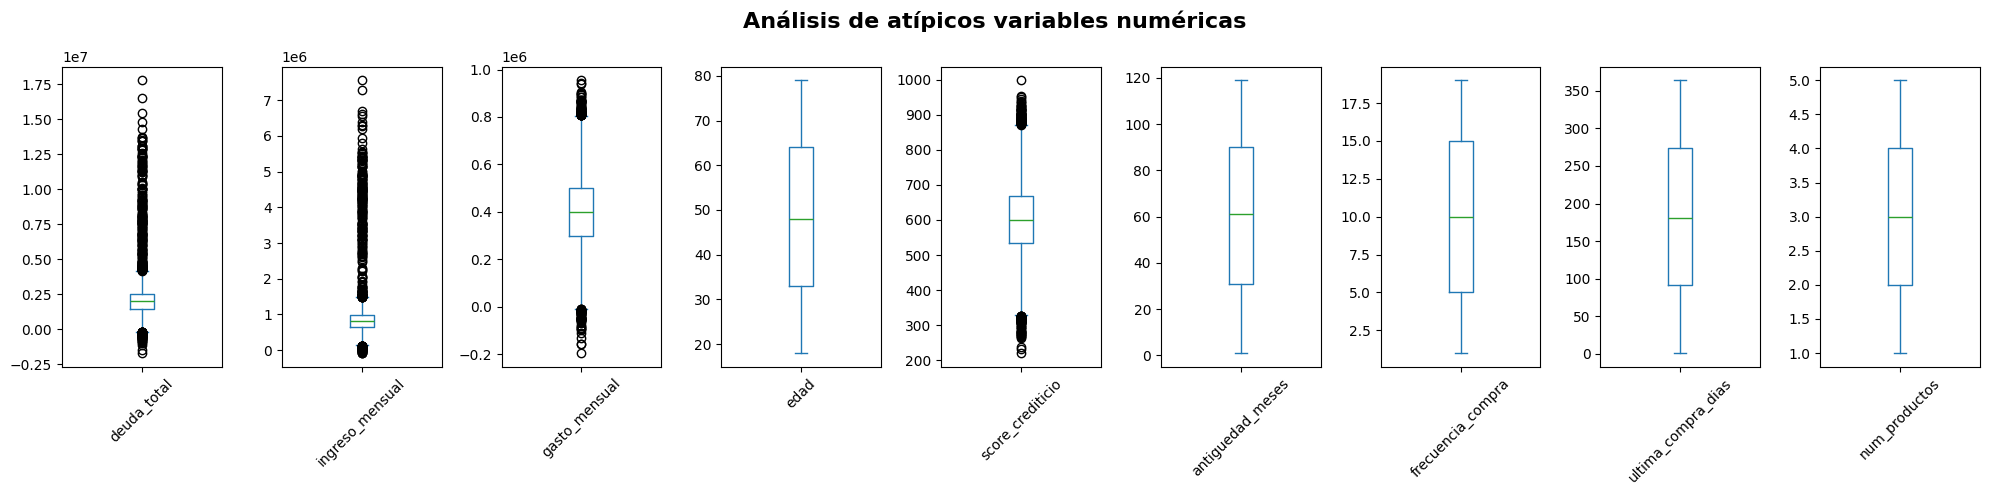

In [ ]:
def visualizar_atipicos_numericos(df):
    """

    Esta función filtra las variables numéricas relevantes según la metadata del negocio
    (excluyendo identificadores, variables espaciales, de tiempo o binarias) y genera un
    lienzo con subgráficos de caja. Esto permite diagnosticar la calidad de los datos
    antes de aplicar métodos de corrección de outliers (como Winsorizer).

    Parámetros:
        df (pd.DataFrame): El conjunto de datos base que contiene la información de los clientes.

    Retorna:
        None: Renderiza la visualización de matplotlib directamente.
    """

    # Lista de columnas numéricas seleccionadas para el análisis
    revision_atipicos = [
        'deuda_total', 'ingreso_mensual', 'gasto_mensual', 'edad',
        'score_crediticio', 'antiguedad_meses', 'frecuencia_compra',
        'ultima_compra_dias', 'num_productos'
    ]

    fig, axes = plt.subplots(1, len(revision_atipicos), figsize=(20, 5))
    axes = axes.flatten() # Convierte la matriz de ejes en un vector

    # Iteramos sobre las columnas para generar cada boxplot
    for i, col in enumerate(revision_atipicos):
        df[col].plot(kind='box', ax=axes[i])
        axes[i].tick_params(axis="x", labelrotation=45)

    # Configuramos los títulos y ajustamos el diseño
    plt.suptitle("Análisis de atípicos variables numéricas", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Visualizamos el grafico:
visualizar_atipicos_numericos(df)

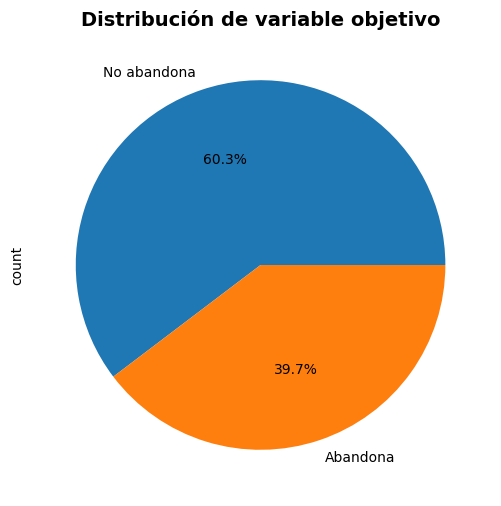

In [ ]:
# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
df[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No abandona', 'Abandona'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()


In [ ]:
# Columnas identificadas con posibles valores negativos o cero que deberían ser positivos
columns_to_correct = [
    "deuda_total", "ingreso_mensual","gasto_mensual", "score_crediticio"
]

for col in columns_to_correct:
    df[col] = df[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


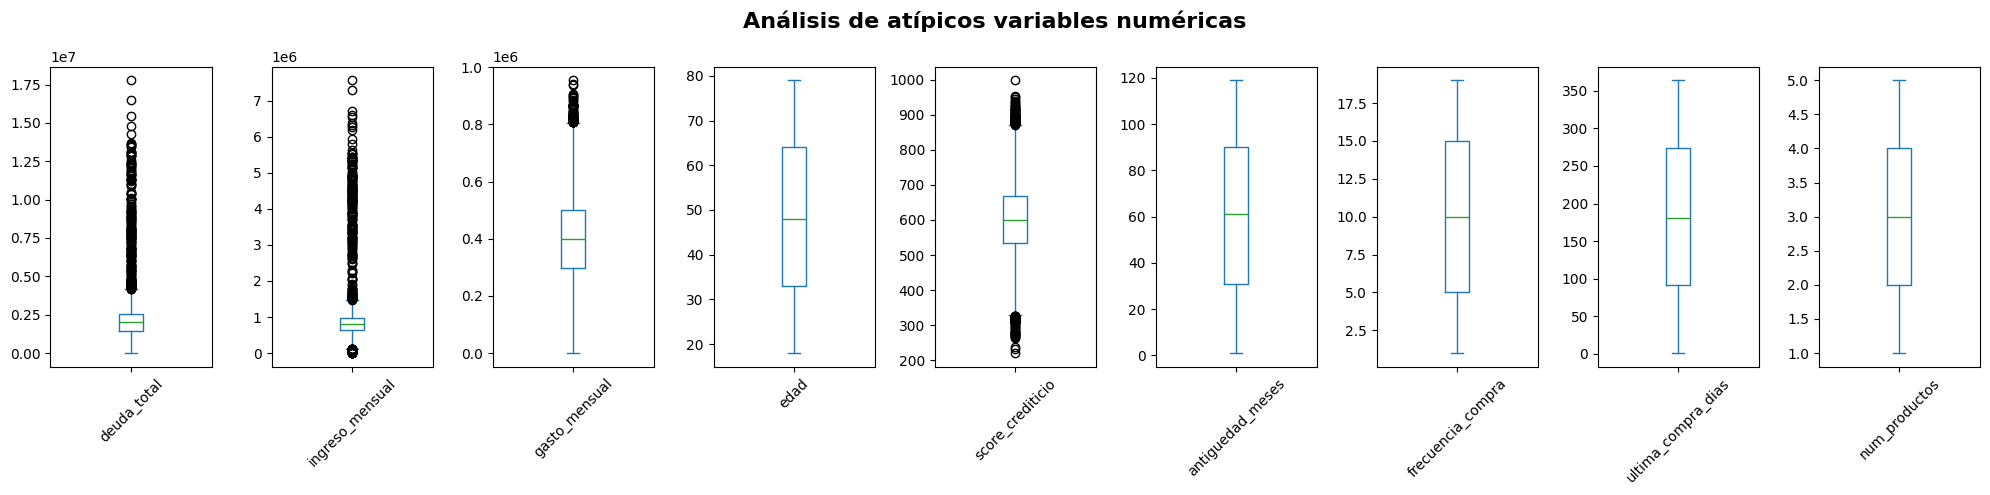

In [ ]:
def visualizar_atipicos_numericos(df):
    """

    Esta función filtra las variables numéricas relevantes según la metadata del negocio
    (excluyendo identificadores, variables espaciales, de tiempo o binarias) y genera un
    lienzo con subgráficos de caja. Esto permite diagnosticar la calidad de los datos
    antes de aplicar métodos de corrección de outliers (como Winsorizer).

    Parámetros:
        df (pd.DataFrame): El conjunto de datos base que contiene la información de los clientes.

    Retorna:
        None: Renderiza la visualización de matplotlib directamente.
    """

    # Lista de columnas numéricas seleccionadas para el análisis
    revision_atipicos = [
        'deuda_total', 'ingreso_mensual', 'gasto_mensual', 'edad',
        'score_crediticio', 'antiguedad_meses', 'frecuencia_compra',
        'ultima_compra_dias', 'num_productos'
    ]

    fig, axes = plt.subplots(1, len(revision_atipicos), figsize=(20, 5))
    axes = axes.flatten() # Convierte la matriz de ejes en un vector

    # Iteramos sobre las columnas para generar cada boxplot
    for i, col in enumerate(revision_atipicos):
        df[col].plot(kind='box', ax=axes[i])
        axes[i].tick_params(axis="x", labelrotation=45)

    # Configuramos los títulos y ajustamos el diseño
    plt.suptitle("Análisis de atípicos variables numéricas", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Visualizamos el grafico:
visualizar_atipicos_numericos(df)

#Preparacion pipline

##Winsorizer

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

##PipelineOrdinal

In [ ]:
pipeline_ordinal_reducido = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(categories=[['Bajo', 'Medio', 'Alto']]))
    ]
)

##Tratamiento de Duplicados

In [ ]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

##Filtro de Correlacion

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

##Convertidor a dataframe

In [ ]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

##Pipelines de estandarizacion de datos

In [ ]:
# Preprocesamiento numérico: imputación con media + estandarización
pipeline_numerico = Pipeline(
        steps=[
            ("winsorizer", Winsorizer(limits=(0.05, 0.05))),
            ("imputacion", SimpleImputer(strategy="mean")),
            ("escalado", StandardScaler())
        ]
    )

# Preprocesamiento categórico: imputación + one-hot encoding
pipeline_nominal = Pipeline(
        steps=[
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
        ]
    )

pipeline_ordinal = Pipeline(
        steps=[
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(categories=[
                ['Bajo', 'Medio', 'Alto'],          # Orden para 'uso_app'
                ['Basico', 'Estandar', 'Premium'],  # Orden para 'tipo_plan'
            ]))
        ]
    )

#Evaluación de las mejores variables predictoras

In [ ]:
# Calcula la matriz de correlaciones
correlaciones = df.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,abandono
abandono,1.000000
ultima_compra_dias,0.212488
deuda_total,0.027574
codigo_postal,0.010975
hora_registro,0.007851
edad,0.006826
ingreso_mensual,0.002623
tiene_tarjeta_credito,-0.000173
num_productos,-0.002758
antiguedad_meses,-0.006739


#Modelamineto

##Visualizacion de variables para verificacion

In [ ]:
#mostrar columnas
df.describe().columns

Index(['id_cliente', 'edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total',
       'score_crediticio', 'antiguedad_meses', 'frecuencia_compra',
       'ultima_compra_dias', 'num_productos', 'tiene_tarjeta_credito',
       'hora_registro', 'codigo_postal', 'abandono'],
      dtype='object')

##Asigancion de columnas a tipo de variable

In [ ]:
"""
Aqui se elimina la variable 'gasto_mensual'
porque al ser la variable objetivo no deberia ir
dentro del pipeline. Eventualmente esto genera un problema
al utilizar el modelo, y es que existiran datos tipo 'Nan'
por lo que el modelo fallará. Se corrige mas adelante
"""
numeric_features = [
    'edad',
    'ingreso_mensual',
    'deuda_total',
    'score_crediticio',
    'antiguedad_meses',
    'frecuencia_compra',
    'ultima_compra_dias',
    'num_productos'
]

categorical_nominal_features = [
    'genero',
    'region',
    'estado_civil',
    'canal_registro',
    'dia_semana_registro',
    'tiene_tarjeta_credito'
]

categorical_ordinal_features = [
    'uso_app',
    'tipo_plan'
]

##Separacion de variable objetivo y variables predictoras

In [ ]:
X = df[numeric_features + categorical_nominal_features+categorical_ordinal_features]
y = df[target]

##Preprocesador

In [ ]:
preprocesador = ColumnTransformer(
        transformers=[
            ("num", pipeline_numerico, numeric_features),
            ("cat_nom", pipeline_nominal, categorical_nominal_features),
            ("cat_ord", pipeline_ordinal, categorical_ordinal_features)
        ]
    )

#Regression

Se utilizó LinearRegression como modelo baseline debido a su simplicidad, interpretabilidad y capacidad de establecer una referencia inicial para comparar modelos más complejos.

In [ ]:
# Objetivo Regresion
"""
Imputamos los valores faltantes en la columna original antes de asignarla a y_reg.
Ya que como se mencionó anteriormente, el haber pasado esta columna sin procesar generaria un error
a la hora de evaluar el modelo
"""

#solo eliminar nan
df_reg = df.dropna(subset=['gasto_mensual'])

X_reg = df_reg.drop(columns=['gasto_mensual', 'id_cliente', 'fecha_registro', 'codigo_postal'], errors='ignore')
y_reg = df_reg['gasto_mensual']

In [ ]:
#Separacion de variables de entrenamineto y test
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=SEED
)

###pipeline regresion lineal

In [ ]:
pipeline_lr = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ('preprocessor', preprocesador),
    ("conversion", DataFrameConverter(preprocesador)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ('model', LinearRegression())
])

El pipeline permite automatizar preprocessing y entrenamiento, asegurando reproducibilidad y evitando data leakage

In [ ]:
pipeline_lr.fit(X_train, y_train)

y_pred = pipeline_lr.predict(X_test)

"""
El modelo intenta predecir 'gasto_mensual'
para los clientes nuevos
"""

"\nEl modelo intenta predecir 'gasto_mensual'\npara los clientes nuevos\n"

###Metricas

In [ ]:
print("MODELO DE REGRESION LINEAL")
#error promedio absoluto.
mae_lr = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae_lr:.3f}")

#Penaliza mucho errores grandes
mse_lr = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse_lr:.3f}")

#vuelve a escala original. más interpretable
rmse_lr = np.sqrt(mse_lr)
print(f"RMSE: {rmse_lr:.3f}")

#Cuánto explica el modelo.
"""
R²	---|--- Interpretación
-------|-------------------
0.8	---|--- excelente
0.5	---|--- moderado
0.2	---|--- bajo
0	  ---|--- no explica nada
"""
r2_lr = r2_score(y_test, y_pred)
print(f"R²: {r2_lr:.3f}")

MODELO DE REGRESION LINEAL
MAE: 120590.371
MSE: 22595611631.993
RMSE: 150318.368
R²: -0.002


**Interpretacion:** El modelo logró capturar parcialmente el comportamiento del gasto mensual, aunque existen desviaciones importantes, lo que sugiere relaciones no completamente lineales.

**Disclaimer** Este modelo, por lo investigado, no cuenta con hiperametros modificables pero es posible utilizar variantes con regularización (Ridge, Lasso o ElasticNet) o modelos entrenados por descenso de gradiente

***Interpretación de las métricas***


**Mean Absolute Error (MAE)**

El MAE obtenido fue de aproximadamente:

120.590

Esto significa que el modelo presenta un error promedio cercano a 120 mil pesos mensuales por cliente.

**Root Mean Squared Error (RMSE)**

El RMSE fue de:

150.318

Esta métrica es una de las más relevantes en regresión, ya que devuelve el error a la escala original del problema. En este caso indica que el modelo posee errores relativamente altos y que existen algunos clientes cuyos gastos mensuales son especialmente difíciles de predecir


**Mean Squared Error (MSE)**

El MSE obtenido fue extremadamente alto:

22.595.611.631

Sin embargo, esta métrica eleva los errores al cuadrado, por lo que suele generar valores muy grandes y difíciles de interpretar directamente

**Coeficiente de Determinación (R²)**

El modelo obtuvo:

−0.002

Un valor negativo indica que el modelo tiene un desempeño peor que simplemente utilizar el promedio de gasto mensual como predicción constante para todos los clientes

###Pipeline arbol de regresion

In [ ]:
pipeline_dtr = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": False})),
    ('preprocessor', preprocesador),
    ("conversion", DataFrameConverter(preprocesador)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ('model', DecisionTreeRegressor(random_state=SEED, max_depth=5))
])

In [ ]:
pipeline_dtr.fit(X_train, y_train)

y_pred = pipeline_dtr.predict(X_test)

In [ ]:
print("MODELO ARBOL DE REGRESION")
#error promedio absoluto.
mae_tree = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae_tree:.3f}")

#Penaliza mucho errores grandes
mse_tree = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse_tree:.3f}")

#vuelve a escala original. más interpretable
rmse_tree = np.sqrt(mse_tree)
print(f"RMSE: {rmse_tree:.3f}")

#Cuánto explica el modelo.
"""
R²	---|--- Interpretación
-------|-------------------
0.8	---|--- excelente
0.5	---|--- moderado
0.2	---|--- bajo
0	  ---|--- no explica nada
"""
r2_tree = r2_score(y_test, y_pred)
print(f"R²: {r2_tree:.3f}")

MODELO ARBOL DE REGRESION
MAE: 121574.252
MSE: 22882558484.287
RMSE: 151269.820
R²: -0.015


**Mean Absolute Error (MAE)**

El modelo presenta un error promedio cercano a:

121.574

Esto indica que el árbol de regresión se equivoca, en promedio, en aproximadamente 121 mil pesos mensuales por cliente.

El resultado es ligeramente peor que el obtenido por la regresión lineal

**Mean Squared Error (MSE)**

El valor elevado del MSE refleja nuevamente la existencia de errores grandes dentro de algunas predicciones realizadas por el modelo.

**Root Mean Squared Error (RMSE)**

El RMSE fue de:

151.269

Este resultado indica que el modelo sigue presentando dificultades importantes para capturar correctamente el comportamiento de gasto de ciertos clientes.

**Coeficiente de Determinación (R²)**

El modelo obtuvo:

−0.015

Este resultado es incluso más bajo que el obtenido por la regresión lineal, indicando que el árbol de regresión tampoco logra explicar adecuadamente la variabilidad del gasto mensual.

#Comparaciones


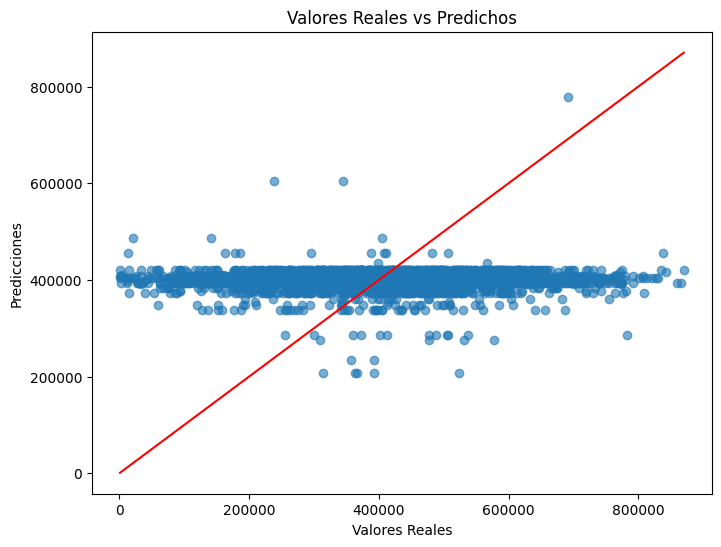

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Valores Reales vs Predichos")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

**En el gráfico se observa que:**

la mayoría de las predicciones se concentran alrededor de un mismo rango,
independientemente del valor real del gasto mensual.

Esto significa que el modelo está prediciendo valores muy similares para casi todos los clientes, en lugar de adaptarse correctamente a las variaciones reales del gasto.

##Grafico de barras comparando modelos

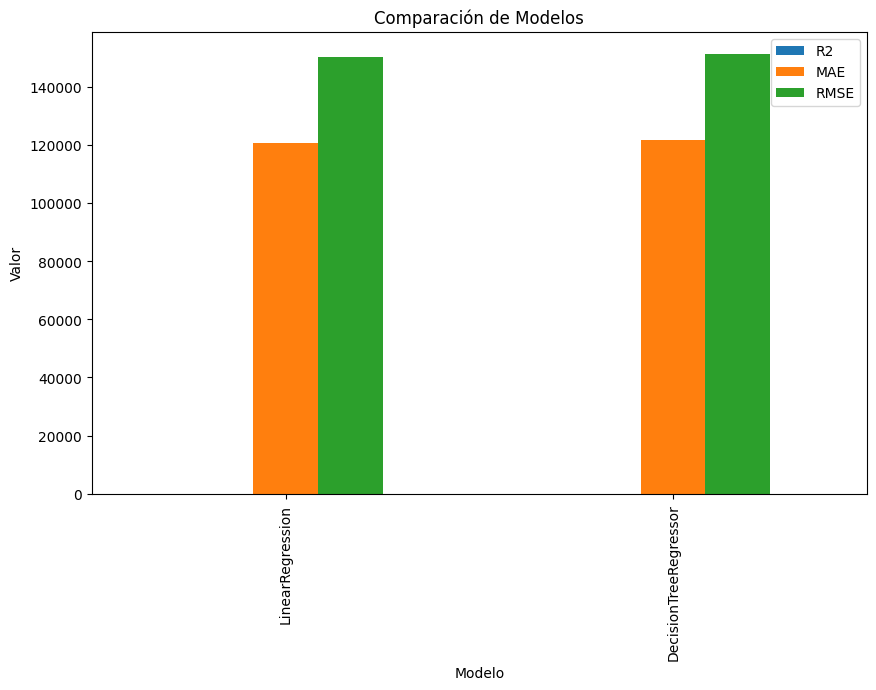

In [ ]:
metricas = pd.DataFrame({
    'Modelo': ['LinearRegression', 'DecisionTreeRegressor'],
    'R2': [r2_lr, r2_tree],
    'MAE': [mae_lr, mae_tree],
    'RMSE': [rmse_lr, rmse_tree]
})

metricas.set_index('Modelo').plot(kind='bar', figsize=(10,6))

plt.title("Comparación de Modelos")
plt.ylabel("Valor")

plt.show()

**Breve conclusion**

Los resultados obtenidos muestran que ninguno de los modelos logra explicar adecuadamente la variabilidad del gasto mensual. Sin embargo, LinearRegression presentó un desempeño ligeramente superior y una mayor interpretabilidad, lo que lo convierte en una mejor alternativa para analizar tendencias generales del comportamiento de gasto|

#Prueba arbol de regresion con hiperparametros

In [ ]:
pipeline_tree = Pipeline([
    ('preprocessor', preprocesador),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [ ]:
"""
Define la rejilla de hiperparámetros (parameter grid) para el proceso de optimización.
Especifica diferentes valores para la profundidad del árbol, el número mínimo de
muestras para dividir un nodo y el mínimo de muestras en cada hoja, los cuales
serán evaluados por GridSearchCV para encontrar la mejor combinación.
"""
param_grid = {
    'model__max_depth': [3, 5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5, 10]
}

In [ ]:
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R²:", r2_best)

MAE: 120643.44123642978
MSE: 22624237244.263947
RMSE: 150413.5540576844
R²: -0.0033471943154950168


In [ ]:
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R²:", r2_best)

MAE: 120643.44123642978
MSE: 22624237244.263947
RMSE: 150413.5540576844
R²: -0.0033471943154950168


In [ ]:
grid_search = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
"""
Aqui se evalua el 'r2' ya que nuestro proposito
es explicar el fenomemo del gasto mensual de
los clientes, y r2 es precisamente quien nos ayuda
a medir y evaluar esto
"""

"\nAqui se evalua el 'r2' ya que nuestro proposito\nes explicar el fenomemo del gasto mensual de\nlos clientes, y r2 es precisamente quien nos ayuda\na medir y evaluar esto\n"

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputacion',
                                                                                          SimpleImputer()),
                                                                                         ('escalado',
                                                                                          StandardScaler())]),
                                                                         ['edad',
                                                                          'ingreso_mensual',
                                                                          'deuda_total',
                                                                          'score_crediticio',
                                                                          'antiguedad_meses',
                                                                          'frecuencia_compra',
                                                                          'ultima_compra_dias',
                                                                          'num_productos']),
                                                                        ('cat_n...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(categories=[['Bajo',
                                                                                                                      'Medio',
                                                                                                                      'Alto'],
                                                                                                                     ['Basico',
                                                                                                                      'Estandar',
                                                                                                                      'Premium']]))]),
                                                                         ['uso_app',
                                                                          'tipo_plan'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 10, 15, None],
                         'model__min_samples_leaf': [1, 2, 5, 10],
                         'model__min_samples_split': [2, 5, 10, 20]},
             scoring='r2', verbose=1)

In [ ]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

Mejores hiperparámetros:
{'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}


In [ ]:
"""
Extrae el mejor estimador (pipeline completo) encontrado durante la búsqueda
de cuadrícula (Grid Search), el cual contiene la combinación óptima de hiperparámetros.
"""
best_model = grid_search.best_estimator_

In [ ]:
"""
Utiliza el mejor modelo obtenido para generar predicciones sobre el conjunto
de prueba (X_test), permitiendo evaluar su desempeño con datos no vistos.
"""
y_pred_best = best_model.predict(X_test)

In [ ]:
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R²:", r2_best)

MAE: 120643.44123642978
MSE: 22624237244.263947
RMSE: 150413.5540576844
R²: -0.0033471943154950168


Incluso optimizando hiperparámetros, el fenómeno sigue siendo difícil de modelar con las variables disponibles

##Comparacion arbol de regresion con y sin hiperparametros

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['Árbol Original', 'Árbol Optimizado'],
    'MAE': [mae_tree, mae_best],
    'RMSE': [rmse_tree, rmse_best],
    'R2': [r2_tree, r2_best]
})

comparacion

,Modelo,MAE,RMSE,R2
0,Árbol Original,121574.251643,151269.820137,-0.014803
1,Árbol Optimizado,120643.441236,150413.554058,-0.003347


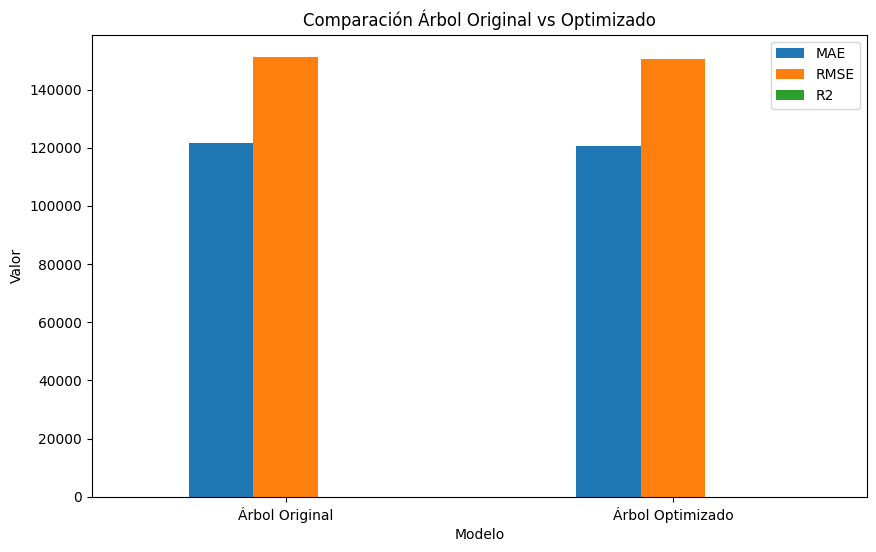

In [ ]:
comparacion.set_index('Modelo').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparación Árbol Original vs Optimizado")
plt.ylabel("Valor")
plt.xticks(rotation=0)

plt.show()